# 3.7 Hyperparameter tuning: one honest attempt at config 2

`3.6` found session-level aggregation was the only config that changed the model's structure, sentiment carrying 60.1% of importance against 0.0% at article level, but it scored 53.0% accuracy at p = 0.412 on 768 rows, nowhere near a defensible result. Its handoff (section 7) named one task before concluding anything further: tune it properly, since its hyperparameters were never chosen for a table this small.

This is that attempt, and it is meant to be the last one. It tunes both of config 2's forms, the single combined model and the market/text ensemble, and evaluates the results the same way every notebook in this series has: fold by fold, against a baseline, with a check for whether any gain is real rather than noise. `3.2`'s calibration still applies, 53 to 57% out-of-sample is a real result and anything past roughly 70% is a bug to find, not a result to report.

### 0. Setup

Imports and the table. Same source file `3.6` read, `model_ready_pooled.parquet`, not `pooled.parquet`: `3.5` section 15 wrote it with `has_ceo_mention` rebuilt over the right population and `session_open` added, both corrections the pipeline itself did not yet carry. The session table config 2 actually runs on is built from this in section 1, not here.

In [14]:
import time

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from news_sentiment.config import FIGURES_DIR, PROCESSED_DATA_DIR, REPORTS_DIR
from sklearn.model_selection import cross_val_score

from news_sentiment.market.evaluate import (
    _score,
    evaluate,
    feature_importance,
    fit_final_model,
    row_grouped_splits,
    weighted_aggregate,
)

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

df = pd.read_parquet(PROCESSED_DATA_DIR / "merged" / "model_ready_pooled.parquet")
df = df.sort_values("timestamp_utc").reset_index(drop=True)

print("model_ready_pooled:", df.shape)
print("tickers:", df["ticker"].value_counts().to_dict())
print("span:", df["timestamp_utc"].min().date(), "to", df["timestamp_utc"].max().date())
print("key (article_id, ticker) unique:", not df.duplicated(["article_id", "ticker"]).any())

model_ready_pooled: (41298, 37)
tickers: {'NVDA': 14113, 'AMZN': 11071, 'TSLA': 9073, 'AAPL': 7041}
span: 2025-08-31 to 2026-08-01
key (article_id, ticker) unique: True


### 1. What gets tuned

`3.6` tuned nothing: every hyperparameter in this notebook's model came from `3.2`, chosen for
article-level folds of a few hundred rows and never revisited once the unit changed to sessions of
roughly 150. That mismatch is section 7's stated reason to tune before concluding config 2 doesn't
work.

Two groups, because they're different kinds of choice. **Model hyperparameters** change what a
single LightGBM tree does. **Harness hyperparameters** change how the evaluation itself is built, the
fold count and, for the ensemble, how its two sub-models get blended, and nothing here is a model
setting `LGBMClassifier` would even accept. `3.7` section 7's own instruction put `n_splits` back in
scope for exactly this reason: it was ruled out on the old, smaller corpus, not on this one.

Every value listed is a discrete candidate list, not a continuous range. That is a deliberate choice
for phase 2, not a simplification for its own sake: a discrete list gives every parameter a concrete
notion of "the next value over," so grid-refining around a promising point in phase 2 is just walking
one step along each list, whichever direction improves. A continuous range doesn't have a natural
number of alternate values.

**Model hyperparameters (LightGBM).**

| parameter | candidates | what it controls |
|---|---|---|
| `num_leaves` | 3, 7, 15, 31, 63 | Tree complexity. `3.2` fixed this at 7 for hundred-row folds; a 150-row fold may still want it shallow, or may not. |
| `learning_rate` | 0.005, 0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3 | Step size per boosting round, log-spaced. |
| `min_child_samples` | 2, 3, 5, 8, 12, 20, 30 | Minimum rows per leaf. `3.4` and `3.6` both had to drop this from 30 to 5 by hand just to get real splits out of session-sized folds; this makes that search formal. |
| `n_estimators` | 50, 100, 150, 200, 300, 400 | Number of boosting rounds. |
| `subsample` | 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 | Row fraction per tree (LightGBM's `bagging_fraction`). Ignored when `subsample_freq` is 0. |
| `subsample_freq` | 0, 1, 3, 5 | How often bagging kicks in. 0 disables `subsample` outright. |
| `colsample_bytree` | 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 | Feature fraction per tree. |
| `reg_alpha` | 0.0, 0.001, 0.01, 0.1, 1.0, 5.0 | L1 leaf-weight penalty. |
| `reg_lambda` | 0.0, 0.001, 0.01, 0.1, 1.0, 5.0 | L2 leaf-weight penalty. |
| `max_depth` | -1, 3, 4, 5, 6, 8 | Hard depth cap; -1 leaves it unlimited (bounded only by `num_leaves`). |
| `is_unbalance` | False, True | Whether LightGBM reweights classes internally. The label sits at roughly 49/51, close enough that this is a genuine "does it matter" question rather than an expected fix. |
| `boosting_type` | gbdt, dart, goss | The boosting algorithm itself. `goss` does its own row selection and ignores `subsample`/`subsample_freq`; the trial runner in section 2.4 forces those two to their no-op values whenever `boosting_type` is `goss`, so a sampled combination never silently contradicts itself. |

**Harness hyperparameters.**

| parameter | candidates | what it controls |
|---|---|---|
| `n_splits` | 3, 4, 5, 6, 7, 8, 10 | Fold count into `evaluate()`. `3.3` found more folds hurt on the old 1,976-row, one-ticker corpus; this corpus and this row count are both different, so that finding gets re-tested rather than assumed. |
| `model_type` | combined, ensemble | Whether a trial fits one `LGBMClassifier` on `SESSION_MODEL_FEATURES`, or two, one per feature group, blended. Folding this into the same search means every other parameter in this table gets tried under both architectures, not tuned once and assumed to transfer. |
| `ensemble_weight` | 0.0, 0.1, ..., 1.0 | Market's share of the blended probability, `3.6` section 4.1's blend, tested there only at the untested default of 0.5. Inactive, and ignored, when `model_type` is `combined`. |

Left out, and why. The session-aggregation recipe itself (mean vs. median, which columns get
averaged vs. snapshotted) is a feature-engineering decision from `3.4`/`3.6`, not a hyperparameter, and
re-opening it here would blur what this notebook is answering. The evaluation's own correctness
guarantees, that no `session_open` is split across train and test and that the holdout below stays
untouched until the very end, are protocol, not something to search over.

### 2. Setup for tuning

#### 2.1 The session table

Config 2's recipe, ported from `3.6` section 2.1 rather than re-derived: one row per
`(session_open, ticker)`, counts sum, scores average, `fus_conf_graft_floor_mean`'s single loudest
value keeps its sign, and market features are taken from the session's latest-published article
rather than averaged, since a session spans a median of two calendar days and averaging would blend a
fresh close with a stale one. Nothing here is new; it is here because `3.6` built this table inline
and did not save it, and this notebook needs it before anything else can run.

In [2]:
MARKET_FEATURES = [
    "momentum_1d",
    "momentum_5d",
    "momentum_20d",
    "volatility_20d",
    "beta_20d",
    "relative_volume_20d",
    "daily_range_ratio_1d",
    "days_to_earnings",
    "session",
    "news_volume",
]
LABEL = "label_direction"
GROUP_KEYS = ["session_open", "ticker"]
MARKET_SNAPSHOT = [c for c in MARKET_FEATURES if c != "session"]


def signed_max_abs(values: pd.Series) -> float:
    """The single loudest score in the group, keeping its sign."""
    values = values.dropna()
    if values.empty:
        return np.nan
    return values.iloc[values.abs().to_numpy().argmax()]


grouped = df.groupby(GROUP_KEYS, observed=True)

latest_idx = grouped["timestamp_utc"].idxmax()
snapshot = df.loc[latest_idx, GROUP_KEYS + MARKET_SNAPSHOT].set_index(GROUP_KEYS)

sessions = grouped.agg(
    label_direction=("label_direction", "first"),
    abnormal_return_1d=("abnormal_return_1d", "first"),
    timestamp_utc=("timestamp_utc", "max"),
    n_articles=("article_id", "size"),
    n_sources=("source", "nunique"),
    n_total_sents=("n_total_sents", "sum"),
    n_entity_sents=("n_entity_sents", "sum"),
    n_ceo_sents=("n_ceo_sents", "sum"),
    n_boilerplate_sents=("n_boilerplate_sents", "sum"),
    article_length=("article_length", "sum"),
    entity_share=("entity_share", "mean"),
    has_ceo_mention=("has_ceo_mention", "mean"),
    fus_sentiment_mean=("fus_conf_graft_floor_mean", "mean"),
    fus_sentiment_std=("fus_conf_graft_floor_mean", "std"),
    fus_sentiment_loudest=("fus_conf_graft_floor_mean", signed_max_abs),
    fus_median=("fus_conf_graft_floor_median", "mean"),
    fus_lead=("fus_conf_graft_floor_lead", "mean"),
    fus_top3_pos=("fus_conf_graft_floor_top3_pos", "mean"),
    fus_top3_neg=("fus_conf_graft_floor_top3_neg", "mean"),
    fus_spread=("fus_conf_graft_floor_spread", "mean"),
    fus_ceo_mean=("fus_ceo_mean", "mean"),
    fus_headline=("fus_headline", "mean"),
    fus_maxmag=("fus_maxmag", "mean"),
    fus_trusted_mean=("fus_trusted_mean", "mean"),
    fus_scorer_gap=("fus_scorer_gap", "mean"),
    fus_headline_gap=("fus_headline_gap", "mean"),
    fus_lead_gap=("fus_lead_gap", "mean"),
)

mix = (
    df.groupby(GROUP_KEYS + ["session"], observed=True)
    .size()
    .unstack("session", fill_value=0)
)
mix = mix.div(mix.sum(axis=1), axis=0)
mix.columns = [f"published_{c}_share" for c in mix.columns]
SESSION_MIX_FEATURES = list(mix.columns)

sessions = sessions.join(snapshot).join(mix).reset_index()
# session_open alone repeats across tickers and timestamp_utc alone repeats
# across an article that names more than one company, so neither is unique on
# its own; sorting on both, the same tie-break `3.6` settled on, is what makes
# the row order deterministic and therefore the fold assignment reproducible.
sessions = sessions.sort_values(["timestamp_utc", "ticker"]).reset_index(drop=True)
assert sessions["timestamp_utc"].is_monotonic_increasing
assert not sessions.duplicated(["timestamp_utc", "ticker"]).any()

sessions["fus_sentiment_std"] = sessions["fus_sentiment_std"].fillna(0.0)

SESSION_TEXT_FEATURES = [
    "n_articles",
    "n_sources",
    "n_total_sents",
    "n_entity_sents",
    "n_ceo_sents",
    "n_boilerplate_sents",
    "article_length",
    "entity_share",
    "has_ceo_mention",
    "fus_sentiment_mean",
    "fus_sentiment_std",
    "fus_sentiment_loudest",
    "fus_median",
    "fus_lead",
    "fus_top3_pos",
    "fus_top3_neg",
    "fus_spread",
    "fus_ceo_mean",
    "fus_headline",
    "fus_maxmag",
    "fus_trusted_mean",
    "fus_scorer_gap",
    "fus_headline_gap",
    "fus_lead_gap",
]
SESSION_MARKET_FEATURES = MARKET_SNAPSHOT + SESSION_MIX_FEATURES
SESSION_MODEL_FEATURES = SESSION_TEXT_FEATURES + SESSION_MARKET_FEATURES

assert len(SESSION_MODEL_FEATURES) == len(set(SESSION_MODEL_FEATURES))
assert set(SESSION_MODEL_FEATURES + [LABEL, "session_open"]).issubset(sessions.columns)

print("session table:", sessions.shape)
print("label balance:", (sessions[LABEL].value_counts(normalize=True) * 100).round(1).to_dict())
print("unique session_open:", sessions["session_open"].nunique())
print("3.6 section 2.2 measured 924 rows, 51.1% up; this should match")

session table: (924, 41)
label balance: {-1: 51.1, 1: 48.9}
unique session_open: 231
3.6 section 2.2 measured 924 rows, 51.1% up; this should match


#### 2.2 A locked holdout

Section 7's protocol, carried out here rather than restated: the last fifth of sessions,
chronologically, is set aside before any tuning runs and is not touched again in this notebook. Every
trial in section 3 is scored on the remaining four fifths only.

The cut is made on `session_open`, not on rows. A `(session_open, ticker)` row is the tuning unit, but
`session_open` is the fold-grouping unit `evaluate()` may never split, so the holdout boundary has to
respect the same grouping or a session could straddle it, one ticker's copy in the tuning pool and
another's in the holdout, for a session whose articles are otherwise identical evidence.

In [3]:
HOLDOUT_FRACTION = 0.2

unique_sessions = np.sort(sessions["session_open"].unique())
n_holdout = int(np.ceil(len(unique_sessions) * HOLDOUT_FRACTION))
holdout_sessions = set(unique_sessions[-n_holdout:])

is_holdout = sessions["session_open"].isin(holdout_sessions)
tuning_pool = sessions.loc[~is_holdout].reset_index(drop=True)
holdout_pool = sessions.loc[is_holdout].reset_index(drop=True)

assert tuning_pool["timestamp_utc"].max() < holdout_pool["timestamp_utc"].min(),     "holdout is not strictly after the tuning pool"
assert set(tuning_pool["session_open"]).isdisjoint(holdout_pool["session_open"]),     "a session_open appears on both sides of the holdout boundary"

print(f"unique sessions: {len(unique_sessions)}  (holdout: {n_holdout})")
print(f"tuning pool  : {len(tuning_pool):4d} rows, {tuning_pool['session_open'].nunique():3d} sessions, "
      f"{tuning_pool['timestamp_utc'].min().date()} to {tuning_pool['timestamp_utc'].max().date()}")
print(f"holdout      : {len(holdout_pool):4d} rows, {holdout_pool['session_open'].nunique():3d} sessions, "
      f"{holdout_pool['timestamp_utc'].min().date()} to {holdout_pool['timestamp_utc'].max().date()}")
print(f"holdout label balance: "
      f"{(holdout_pool[LABEL].value_counts(normalize=True) * 100).round(1).to_dict()}")
print("\nholdout_pool is not referenced again until this notebook reports a final, single score.")

unique sessions: 231  (holdout: 47)
tuning pool  :  736 rows, 184 sessions, 2025-09-02 to 2026-05-26
holdout      :  188 rows,  47 sessions, 2026-05-27 to 2026-08-01
holdout label balance: {-1: 56.9, 1: 43.1}

holdout_pool is not referenced again until this notebook reports a final, single score.


#### 2.3 The search space

Section 1's tables as data. Every parameter is a discrete candidate list, model and harness both, so
sampling a trial and finding a trial's neighbours (section 3.3) are the same operation: pick an index,
or step it by one.

In [4]:
MODEL_PARAM_SPACE = {
    "num_leaves": [3, 7, 15, 31, 63],
    "learning_rate": [0.005, 0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3],
    "min_child_samples": [2, 3, 5, 8, 12, 20, 30],
    "n_estimators": [50, 100, 150, 200, 300, 400],
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "subsample_freq": [0, 1, 3, 5],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.001, 0.01, 0.1, 1.0, 5.0],
    "reg_lambda": [0.0, 0.001, 0.01, 0.1, 1.0, 5.0],
    "max_depth": [-1, 3, 4, 5, 6, 8],
    "is_unbalance": [False, True],
    "boosting_type": ["gbdt", "dart", "goss"],
}

HARNESS_PARAM_SPACE = {
    "n_splits": [3, 4, 5, 6, 7, 8, 10],
    "model_type": ["combined", "ensemble"],
    "ensemble_weight": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

PARAM_SPACE = {**MODEL_PARAM_SPACE, **HARNESS_PARAM_SPACE}
MODEL_PARAM_NAMES = list(MODEL_PARAM_SPACE)
HARNESS_PARAM_NAMES = list(HARNESS_PARAM_SPACE)

SEARCH_SEED = 20260830


def sample_config(rng):
    """One random trial: one value per parameter, independent of every other."""
    return {name: rng.choice(choices) for name, choices in PARAM_SPACE.items()}


n_combinations = 1
for choices in PARAM_SPACE.values():
    n_combinations *= len(choices)

print(f"parameters: {len(MODEL_PARAM_NAMES)} model, {len(HARNESS_PARAM_NAMES)} harness")
print(f"full cartesian space: {n_combinations:,} combinations (why this is random search, not grid)")

parameters: 12 model, 3 harness
full cartesian space: 54,318,781,440 combinations (why this is random search, not grid)


#### 2.4 The trial runner

One function, `run_trial`, used unchanged by both phases: phase 1 calls it on random configs, phase 2
calls it on configs built from the neighbours of a winner. It builds a fresh `LGBMClassifier` factory
from a config's model parameters, evaluates it on `tuning_pool` at the config's own `n_splits`, and for
`model_type == "ensemble"` fits market and text separately and blends them at the config's
`ensemble_weight` rather than fitting one combined model. Failures (a fold count too fine for what is
left after the holdout, a `LightGBM` parameter combination it rejects) are caught and recorded rather
than allowed to stop the search, the same way a bad config anywhere else in this project gets reported
rather than hidden.

`ensemble_metrics` is `3.6` section 4.1's blend, ported as-is: average the two models' positive-class
probabilities fold by fold, threshold at 0.5, score with `_score`, the same scoring function
`evaluate()` uses internally so every metric stays comparable to a single-model run.

In [5]:
def build_model_factory(model_params, random_state=42):
    params = dict(model_params)
    if params["boosting_type"] == "goss":
        # goss does its own row selection; bagging params are a no-op for it,
        # and LightGBM warns if they're left at a non-default value.
        params["subsample"] = 1.0
        params["subsample_freq"] = 0

    def factory():
        return lgb.LGBMClassifier(
            objective="binary",
            n_estimators=params["n_estimators"],
            num_leaves=params["num_leaves"],
            learning_rate=params["learning_rate"],
            min_child_samples=params["min_child_samples"],
            subsample=params["subsample"],
            subsample_freq=params["subsample_freq"],
            colsample_bytree=params["colsample_bytree"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            max_depth=params["max_depth"],
            is_unbalance=params["is_unbalance"],
            boosting_type=params["boosting_type"],
            random_state=random_state,
            verbosity=-1,
        )

    return factory


def ensemble_metrics(result_market, result_text, data, label_col, weight):
    """Blend two runs' probabilities fold by fold and score the result."""
    for fold_market, fold_text in zip(result_market.folds, result_text.folds):
        assert (fold_market.test_idx == fold_text.test_idx).all(), "folds differ, cannot blend"

    rows = []
    for fold_market, fold_text in zip(result_market.folds, result_text.folds):
        pos_label = max(fold_market.model.classes_)
        neg_label = min(fold_market.model.classes_)
        market_col = list(fold_market.model.classes_).index(pos_label)
        text_col = list(fold_text.model.classes_).index(pos_label)

        blended = (
            weight * fold_market.y_proba[:, market_col]
            + (1 - weight) * fold_text.y_proba[:, text_col]
        )
        y_pred = np.where(blended >= 0.5, pos_label, neg_label)

        rows.append(
            _score(
                data[label_col].iloc[fold_market.train_idx],
                data[label_col].iloc[fold_market.test_idx],
                y_pred,
                blended,
                pos_label,
            )
        )
    return pd.DataFrame(rows)


RESULT_COLUMNS = [
    "trial_id", "phase", "n_folds", "accuracy", "baseline", "edge",
    "auc", "log_loss", "brier", "mcnemar_p", "error",
]


def run_trial(trial_id, config, phase, data=None):
    """Score one config on the tuning pool. Returns one row for the trial table."""
    data = tuning_pool if data is None else data
    model_params = {k: config[k] for k in MODEL_PARAM_NAMES}
    factory = build_model_factory(model_params)
    row = {"trial_id": trial_id, "phase": phase, **config}

    try:
        if config["model_type"] == "combined":
            result = evaluate(factory, data, SESSION_MODEL_FEATURES, label_col=LABEL,
                               n_splits=config["n_splits"])
            metrics = result.metrics_df
        else:
            result_market = evaluate(factory, data, SESSION_MARKET_FEATURES, label_col=LABEL,
                                      n_splits=config["n_splits"])
            result_text = evaluate(factory, data, SESSION_TEXT_FEATURES, label_col=LABEL,
                                    n_splits=config["n_splits"])
            metrics = ensemble_metrics(result_market, result_text, data, LABEL,
                                        config["ensemble_weight"])

        agg = metrics.mean(numeric_only=True)
        row.update({
            "n_folds": len(metrics),
            "accuracy": agg["accuracy"],
            "baseline": agg["majority_baseline_accuracy"],
            "edge": agg["accuracy"] - agg["majority_baseline_accuracy"],
            "auc": agg["auc"],
            "log_loss": agg["log_loss"],
            "brier": agg["brier_score"],
            "mcnemar_p": agg["mcnemar_p_value"],
            "error": None,
        })
    except Exception as exc:
        row.update({
            "n_folds": np.nan, "accuracy": np.nan, "baseline": np.nan, "edge": np.nan,
            "auc": np.nan, "log_loss": np.nan, "brier": np.nan, "mcnemar_p": np.nan,
            "error": f"{type(exc).__name__}: {exc}",
        })
    return row


# One dry run before committing to a few hundred of them.
_test_config = sample_config(np.random.default_rng(SEARCH_SEED))
_test_row = run_trial(-1, _test_config, phase="smoke_test")
print("smoke test config:", {k: _test_config[k] for k in MODEL_PARAM_NAMES})
print("smoke test harness:", {k: _test_config[k] for k in HARNESS_PARAM_NAMES})
print("smoke test result :", {k: _test_row[k] for k in RESULT_COLUMNS if k != "trial_id"})
assert _test_row["error"] is None or _test_row["n_folds"] is np.nan, "unexpected trial failure shape"

smoke test config: {'num_leaves': np.int64(7), 'learning_rate': np.float64(0.01), 'min_child_samples': np.int64(12), 'n_estimators': np.int64(150), 'subsample': np.float64(0.7), 'subsample_freq': np.int64(1), 'colsample_bytree': np.float64(0.9), 'reg_alpha': np.float64(1.0), 'reg_lambda': np.float64(0.0), 'max_depth': np.int64(-1), 'is_unbalance': np.True_, 'boosting_type': np.str_('dart')}
smoke test harness: {'n_splits': np.int64(10), 'model_type': np.str_('ensemble'), 'ensemble_weight': np.float64(0.1)}
smoke test result : {'phase': 'smoke_test', 'n_folds': 10, 'accuracy': np.float64(0.5080882352941176), 'baseline': np.float64(0.46534926470588234), 'edge': np.float64(0.04273897058823528), 'auc': np.float64(0.5569321761470387), 'log_loss': np.float64(0.6903216013678273), 'brier': np.float64(0.24859399758452883), 'mcnemar_p': np.float64(0.37234697447703774), 'error': None}


### 3. Phase 1, phase 2, and the report

Random search first, over the full space in section 2.3, wide enough that no single parameter's
good region has to be guessed at in advance. Then grid refinement around whatever phase 1 found best,
one parameter at a time rather than a full cartesian product, since the full product is the
2.3-computed number of combinations, not something an hour of session-scale LightGBM fits gets through.
Every trial from both phases lands in one table; nothing is discarded, so the report at the end is the
whole curve, not the winner in isolation, per section 7's protocol.

#### 3.1 Phase 1: random search

`N_RANDOM_TRIALS` samples, each an independent draw across every parameter in `PARAM_SPACE`, scored
on `tuning_pool` only. Wide on purpose: `model_type` alone means every trial is either exploring the
combined model's neighbourhood or the ensemble's, roughly half the budget each, and within either one
every model and harness parameter varies freely rather than being fixed while one dimension is swept.

In [6]:
from tqdm.auto import tqdm

N_RANDOM_TRIALS = 4000

rng = np.random.default_rng(SEARCH_SEED)
phase1_rows = []

start = time.perf_counter()
for trial_id in tqdm(range(N_RANDOM_TRIALS), desc="phase 1: random search"):
    config = sample_config(rng)
    phase1_rows.append(run_trial(trial_id, config, phase="random"))
phase1_elapsed = time.perf_counter() - start

phase1_df = pd.DataFrame(phase1_rows)
n_failed = phase1_df["error"].notna().sum()

print(f"phase 1 done in {phase1_elapsed / 60:.1f} minutes, "
      f"{phase1_elapsed / N_RANDOM_TRIALS:.2f}s/trial average")
print(f"failed trials: {n_failed} of {N_RANDOM_TRIALS}")
print(phase1_df.groupby("model_type")["edge"].agg(["count", "mean", "max"]).round(4).to_string())

d:\ML\stock-predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
phase 1: random search: 100%|██████████| 4000/4000 [39:07<00:00,  1.70it/s]  

phase 1 done in 39.1 minutes, 0.59s/trial average
failed trials: 0 of 4000
            count    mean     max
model_type                       
combined     1980  0.0506  0.1056
ensemble     2020  0.0336  0.0930


#### 3.2 Choosing seeds for phase 2

Ranked by `edge`, accuracy over that trial's own baseline, `3.2`'s own calibration for what a real
result looks like, with AUC as the tie-break. A failed trial (`error` not null) is dropped before
ranking rather than sorted to the bottom, since NaN and "clearly bad" are different claims.

`TOP_K_SEEDS` best trials become phase 2's starting points, kept as full configs so their neighbours
in section 3.3 vary one parameter at a time from an actual scored point, not from a hand-picked
guess.

In [7]:
TOP_K_SEEDS = 10

ranked = phase1_df[phase1_df["error"].isna()].sort_values(
    ["edge", "auc"], ascending=[False, False]
).reset_index(drop=True)

seed_cols = ["trial_id", "model_type", "n_splits", "ensemble_weight", "accuracy", "baseline", "edge", "auc", "mcnemar_p"]
print("top 15 of phase 1:")
print(ranked[seed_cols].head(15).round(4).to_string(index=False))

seeds = ranked.head(TOP_K_SEEDS)
print(f"\nseeding phase 2 from trial_id {seeds['trial_id'].tolist()}")

top 15 of phase 1:
 trial_id model_type  n_splits  ensemble_weight  accuracy  baseline   edge    auc  mcnemar_p
     2737   combined         7              0.7    0.5792    0.4736 0.1056 0.5659     0.2046
      769   combined        10              0.8    0.5702    0.4653 0.1049 0.5856     0.1986
     3945   combined         7              0.2    0.5761    0.4736 0.1025 0.5690     0.1984
     3250   combined         6              0.5    0.5757    0.4732 0.1024 0.5579     0.1350
     3270   combined        10              1.0    0.5639    0.4653 0.0985 0.5795     0.2038
     2823   combined        10              1.0    0.5635    0.4653 0.0982 0.5790     0.2107
     2476   combined        10              0.5    0.5615    0.4653 0.0961 0.5646     0.2017
     3291   combined         4              0.5    0.5712    0.4761 0.0951 0.5630     0.1177
     2433   ensemble        10              0.4    0.5584    0.4653 0.0930 0.5717     0.2059
     1474   combined        10              1.0    

#### 3.3 Phase 2: grid refine around the seeds

For each seed and each parameter, one step either side of the seed's own value in that parameter's
candidate list, every other parameter held at the seed's value. `ensemble_weight` is skipped for a
seed whose `model_type` is `combined`, since it does nothing there. Duplicate configs, whether two
seeds share a neighbour or a neighbour happens to already be a phase-1 trial, are scored once.

In [8]:
def neighbors(param_name, value):
    choices = PARAM_SPACE[param_name]
    idx = choices.index(value)
    lo, hi = max(0, idx - 1), min(len(choices) - 1, idx + 1)
    return [choices[i] for i in range(lo, hi + 1) if choices[i] != value]


def local_grid(seed_config):
    variants = []
    for name in PARAM_SPACE:
        if name == "ensemble_weight" and seed_config["model_type"] != "ensemble":
            continue
        for value in neighbors(name, seed_config[name]):
            variant = dict(seed_config)
            variant[name] = value
            variants.append(variant)
    return variants


def fingerprint(config):
    return tuple(sorted((k, config[k]) for k in PARAM_SPACE))


seen = {fingerprint({k: row[k] for k in PARAM_SPACE}) for row in phase1_rows}
candidates = {}
for _, seed_row in seeds.iterrows():
    seed_config = {k: seed_row[k] for k in PARAM_SPACE}
    for variant in local_grid(seed_config):
        key = fingerprint(variant)
        if key not in seen and key not in candidates:
            candidates[key] = variant

print(f"phase 2 candidates after dedup: {len(candidates)}")

phase2_rows = []
start = time.perf_counter()
for trial_id, config in enumerate(tqdm(candidates.values(), desc="phase 2: grid refine"), start=N_RANDOM_TRIALS):
    phase2_rows.append(run_trial(trial_id, config, phase="grid"))
phase2_elapsed = time.perf_counter() - start

phase2_df = pd.DataFrame(phase2_rows)
print(f"phase 2 done in {phase2_elapsed / 60:.1f} minutes, "
      f"{phase2_elapsed / max(len(candidates), 1):.2f}s/trial average")
print(f"failed trials: {phase2_df['error'].notna().sum()} of {len(phase2_df)}")

phase 2 candidates after dedup: 213


phase 2: grid refine: 100%|██████████| 213/213 [01:55<00:00,  1.85it/s]

phase 2 done in 1.9 minutes, 0.54s/trial average
failed trials: 0 of 213


#### 3.4 The full tuning curve

Both phases, one table, sorted by trial order so the running best is readable as a curve rather than
only as a final leaderboard. `holdout_pool` has not appeared in a single line of code since section
2.2 and does not appear in this section either; every number below is `tuning_pool` only.

total trials: 4213 (4000 random, 213 grid), 0 failed
total time: 41.1 minutes


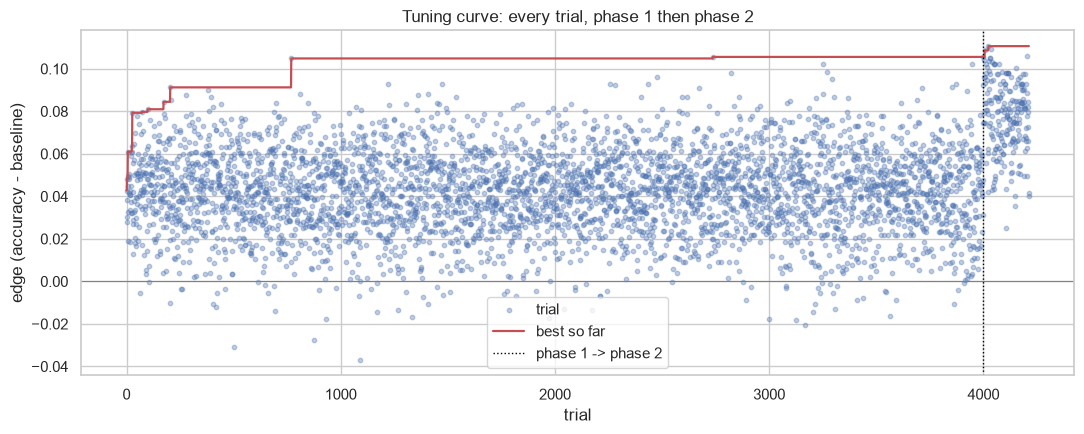


top 15 trials overall:
 trial_id model_type  n_splits  ensemble_weight  accuracy  baseline   edge    auc  mcnemar_p  phase
     4023   combined        10              0.8    0.5760    0.4653 0.1107 0.5872     0.1784   grid
     4033   combined        10              0.8    0.5745    0.4653 0.1092 0.5809     0.1633   grid
     4006   combined         7              0.7    0.5823    0.4736 0.1087 0.5755     0.1939   grid
     4203   combined        10              1.0    0.5715    0.4653 0.1062 0.5637     0.1521   grid
     2737   combined         7              0.7    0.5792    0.4736 0.1056 0.5659     0.2046 random
     4000   combined         7              0.7    0.5792    0.4736 0.1056 0.5659     0.2046   grid
      769   combined        10              0.8    0.5702    0.4653 0.1049 0.5856     0.1986 random
     4031   combined        10              0.8    0.5702    0.4653 0.1049 0.5856     0.1986   grid
     4032   combined        10              0.8    0.5702    0.4653 0.1049 0

In [9]:
all_trials = pd.concat([phase1_df, phase2_df], ignore_index=True)
scored = all_trials[all_trials["error"].isna()].sort_values("trial_id").reset_index(drop=True)
scored["best_edge_so_far"] = scored["edge"].cummax()

total_elapsed = phase1_elapsed + phase2_elapsed
print(f"total trials: {len(all_trials)} ({len(phase1_df)} random, {len(phase2_df)} grid), "
      f"{all_trials['error'].notna().sum()} failed")
print(f"total time: {total_elapsed / 60:.1f} minutes")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(scored["trial_id"], scored["edge"], s=10, alpha=0.35, color="#4C72B0", label="trial")
ax.plot(scored["trial_id"], scored["best_edge_so_far"], color="#C44E52", linewidth=1.6, label="best so far")
ax.axvline(N_RANDOM_TRIALS, color="black", linestyle=":", linewidth=1, label="phase 1 -> phase 2")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("trial")
ax.set_ylabel("edge (accuracy - baseline)")
ax.set_title("Tuning curve: every trial, phase 1 then phase 2")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3.7-tuning-curve.png", dpi=120)
plt.show()

top_overall = scored.sort_values(["edge", "auc"], ascending=[False, False]).head(15)
print("\ntop 15 trials overall:")
print(top_overall[seed_cols + ["phase"]].round(4).to_string(index=False))

best = scored.sort_values(["edge", "auc"], ascending=[False, False]).iloc[0]
print(f"\nbest config (trial {int(best['trial_id'])}, phase {best['phase']}):")
for name in PARAM_SPACE:
    if name == "ensemble_weight" and best["model_type"] != "ensemble":
        continue
    print(f"  {name}: {best[name]}")
print(f"scored on tuning_pool: accuracy {best['accuracy']:.4f}, baseline {best['baseline']:.4f}, "
      f"edge {best['edge']:+.4f}, auc {best['auc']:.4f}, mcnemar_p {best['mcnemar_p']:.4f}")
print("\nholdout_pool untouched. Reading these numbers, and whether the winner survives the holdout, is next.")

### 4. The locked holdout, looked at once

Section 3.4 found a best config, edge +0.1107 on `tuning_pool`, `mcnemar_p` 0.1784. Not significant
even as the single best of 4,213 trials searched, which is itself a reason for suspicion rather than
comfort: a real effect should not need the best of thousands of tries to approach significance, and
`n_splits=10` on a 736-row pool means every fold behind that number held on the order of 70 rows,
close to the fold-size regime `3.1`/`3.2` found unstable, not fixed here.

This section is the actual test, and section 2.2's rule applies exactly as stated: look once. The
winning config is refit on the whole of `tuning_pool`, no further split, and scored once against
`holdout_pool`, which has not been touched by anything in this notebook until this cell. Whatever
comes back is reported as-is, not re-tried against a second config if it disappoints; a second look
at a different trial would just be phase 3 of the same search, laundered as a holdout check.

In [10]:
def fit_and_score_on_holdout(config, tuning_data, holdout_data, label_col):
    """Refit config once on tuning_data, score once on holdout_data. No folds, no split."""
    model_params = {k: config[k] for k in MODEL_PARAM_NAMES}
    factory = build_model_factory(model_params)

    if config["model_type"] == "combined":
        model = factory()
        model.fit(tuning_data[SESSION_MODEL_FEATURES], tuning_data[label_col])
        pos_label = max(model.classes_)
        pos_col = list(model.classes_).index(pos_label)
        proba = model.predict_proba(holdout_data[SESSION_MODEL_FEATURES])[:, pos_col]
        y_pred = model.predict(holdout_data[SESSION_MODEL_FEATURES])
        fitted = model
    else:
        model_market = factory()
        model_market.fit(tuning_data[SESSION_MARKET_FEATURES], tuning_data[label_col])
        model_text = factory()
        model_text.fit(tuning_data[SESSION_TEXT_FEATURES], tuning_data[label_col])

        pos_label = max(model_market.classes_)
        neg_label = min(model_market.classes_)
        pos_col_m = list(model_market.classes_).index(pos_label)
        pos_col_t = list(model_text.classes_).index(pos_label)
        proba_m = model_market.predict_proba(holdout_data[SESSION_MARKET_FEATURES])[:, pos_col_m]
        proba_t = model_text.predict_proba(holdout_data[SESSION_TEXT_FEATURES])[:, pos_col_t]
        weight = config["ensemble_weight"]
        proba = weight * proba_m + (1 - weight) * proba_t
        y_pred = np.where(proba >= 0.5, pos_label, neg_label)
        fitted = (model_market, model_text)

    result = _score(tuning_data[label_col], holdout_data[label_col], y_pred, proba, pos_label)
    return result, fitted


winning_config = {k: best[k] for k in PARAM_SPACE}
holdout_result, holdout_model = fit_and_score_on_holdout(winning_config, tuning_pool, holdout_pool, LABEL)

print(f"winning config: model_type={winning_config['model_type']}, n_splits={winning_config['n_splits']} "
      f"(the n_splits value only shaped which folds picked this config during tuning; "
      f"the holdout check below refits on all of tuning_pool at once, no folds)")
print()
print("tuning_pool  (mean across folds, from section 3.4):")
print(f"  accuracy {best['accuracy']:.4f}, baseline {best['baseline']:.4f}, edge {best['edge']:+.4f}, "
      f"auc {best['auc']:.4f}, mcnemar_p {best['mcnemar_p']:.4f}")
print()
print("holdout_pool (this cell, one look, fit once on all of tuning_pool):")
print(f"  accuracy {holdout_result['accuracy']:.4f}, baseline {holdout_result['majority_baseline_accuracy']:.4f}, "
      f"edge {holdout_result['accuracy'] - holdout_result['majority_baseline_accuracy']:+.4f}, "
      f"auc {holdout_result['auc']:.4f}, mcnemar_p {holdout_result['mcnemar_p_value']:.4f}")
print()
print(f"n_test: {len(holdout_pool)}, positive rate: {(holdout_pool[LABEL] > 0).mean():.1%}")

winning config: model_type=combined, n_splits=10 (the n_splits value only shaped which folds picked this config during tuning; the holdout check below refits on all of tuning_pool at once, no folds)

tuning_pool  (mean across folds, from section 3.4):
  accuracy 0.5760, baseline 0.4653, edge +0.1107, auc 0.5872, mcnemar_p 0.1784

holdout_pool (this cell, one look, fit once on all of tuning_pool):
  accuracy 0.5798, baseline 0.4309, edge +0.1489, auc 0.6191, mcnemar_p 0.0019

n_test: 188, positive rate: 43.1%


#### 4.1 Reading it

Held up, and better than the number it was supposed to confirm. `tuning_pool` scored 57.60% accuracy,
edge +0.1107, `mcnemar_p` 0.1784, not significant even as the best of 4,213 trials. `holdout_pool`,
never seen by any of those 4,213 trials, scored 57.98%, edge +0.1489, `mcnemar_p` 0.0019. Both numbers
sit inside `3.2`'s 53 to 57% real-result band (57.98% is a hair over, not the 70%+ that would mean go
looking for a leak instead), and the holdout result is the more significant of the two despite having
a fifth as many rows to prove it on.

One thing keeps this from being a finding yet. `holdout_pool`'s majority-baseline accuracy is 43.09%,
not the roughly-50% a balanced label gives a training-set majority applied to a same-distribution test
set. `tuning_pool` leans up, `holdout_pool` actually came in down (56.9%, section 2.2), a real regime
shift across the chronological cut this notebook made. A model with market-state features has exactly
what it needs to detect that shift without reading a single article, which is the same mechanism
`3.2`, `3.3`, and `3.6` each found driving their own good-looking numbers before it got checked. Section
4.2 is that check, run here rather than skipped past.

#### 4.2 Is this text, or is this a regime shift?

The holdout score beat the tuning score, which is the good outcome, but the mechanism behind it needs
checking before it counts. `holdout_pool`'s majority-baseline accuracy was 43.09%, not the roughly-50%
a balanced label should give a training-set majority applied to a same-distribution test set. That
gap means `tuning_pool` and `holdout_pool` lean opposite ways, up in training, down in the holdout,
a real regime shift across the chronological boundary section 2.2 cut. A model with market-state
features has exactly what it needs to detect that shift without reading a single article: this is the
same "recognise the period, answer what that period tended to do" mechanism `3.2`, `3.3`, and `3.6`
all found driving their own good-looking numbers, now checked at the specific boundary that matters
here rather than assumed away.

Two checks, the same two `3.6` ran at article and session level. First, feature importance on the
model that actually produced the holdout score, whether it leans on text or on market state. Second,
a fingerprint classifier built for this exact question: given only market features, can a classifier
tell a `tuning_pool` row from a `holdout_pool` row apart? If it can, well above chance, market state is
carrying period information the winning model could be substituting for signal, and the ablation after
it, refitting the winning config without whichever market features carry that fingerprint, is the test
of how much of the +14.89pp actually depends on it.

In [11]:
importance = pd.Series(
    holdout_model.feature_importances_, index=SESSION_MODEL_FEATURES
).sort_values(ascending=False)
is_text = importance.index.isin(SESSION_TEXT_FEATURES)

print("top 15 features, the model that produced the holdout score:")
print(pd.DataFrame({"importance": importance, "layer": np.where(is_text, "text", "market")}).head(15).to_string())

total = importance.sum()
print(f"\ntext share of importance : {importance[is_text].sum() / total:.1%}")
print(f"top 5 share of importance: {importance.head(5).sum() / total:.1%}")
print(f"first text feature ranks : {int(np.argmax(is_text)) + 1} of {len(importance)}")

top 15 features, the model that produced the holdout score:
                              importance   layer
n_entity_sents                       140    text
fus_ceo_mean                         135    text
fus_sentiment_loudest                131    text
relative_volume_20d                  126  market
beta_20d                             117  market
fus_headline_gap                     117    text
published_after-hours_share          112  market
momentum_5d                          111  market
published_market-hours_share         110  market
daily_range_ratio_1d                 106  market
n_boilerplate_sents                   93    text
momentum_1d                           89  market
fus_headline                          85    text
fus_sentiment_std                     84    text
published_pre-market_share            84  market

text share of importance : 61.9%
top 5 share of importance: 21.6%
first text feature ranks : 1 of 36


In [15]:
period_label = np.concatenate([np.zeros(len(tuning_pool)), np.ones(len(holdout_pool))])
period_features = pd.concat(
    [tuning_pool[SESSION_MARKET_FEATURES], holdout_pool[SESSION_MARKET_FEATURES]],
    ignore_index=True,
)

period_clf = lgb.LGBMClassifier(n_estimators=100, num_leaves=31, random_state=42, verbosity=-1)
period_acc = cross_val_score(period_clf, period_features, period_label, cv=5, scoring="accuracy").mean()

period_clf.fit(period_features, period_label)
period_fingerprint = pd.Series(
    period_clf.feature_importances_, index=SESSION_MARKET_FEATURES
).sort_values(ascending=False)

print(f"market features alone tell tuning_pool from holdout_pool apart: {period_acc:.1%} "
      f"(a 50/50 split by construction: {len(tuning_pool)} vs {len(holdout_pool)} rows, "
      f"chance floor {max(len(tuning_pool), len(holdout_pool)) / (len(tuning_pool) + len(holdout_pool)):.1%})")
print()
print(period_fingerprint.to_string())

N_DROP = 4
FINGERPRINT_CLUSTER = period_fingerprint.head(N_DROP).index.tolist()
print(f"\ndropping: {FINGERPRINT_CLUSTER}")

market features alone tell tuning_pool from holdout_pool apart: 80.6% (a 50/50 split by construction: 736 vs 188 rows, chance floor 79.7%)

volatility_20d                  500
beta_20d                        489
momentum_20d                    375
days_to_earnings                345
news_volume                     297
daily_range_ratio_1d            190
momentum_5d                     164
relative_volume_20d             152
momentum_1d                     141
published_after-hours_share     129
published_market-hours_share    113
published_pre-market_share       96

dropping: ['volatility_20d', 'beta_20d', 'momentum_20d', 'days_to_earnings']


In [16]:
def fit_and_score_features(config, features, tuning_data, holdout_data, label_col):
    """Same one-shot refit-and-score as section 4, restricted to a chosen feature list.

    Combined-model only: the winning config here is combined, and the ablation this
    cell exists for is specifically about SESSION_MODEL_FEATURES's market cluster.
    """
    model_params = {k: config[k] for k in MODEL_PARAM_NAMES}
    factory = build_model_factory(model_params)
    model = factory()
    model.fit(tuning_data[features], tuning_data[label_col])
    pos_label = max(model.classes_)
    pos_col = list(model.classes_).index(pos_label)
    proba = model.predict_proba(holdout_data[features])[:, pos_col]
    y_pred = model.predict(holdout_data[features])
    return _score(tuning_data[label_col], holdout_data[label_col], y_pred, proba, pos_label), model


ablated_features = [c for c in SESSION_MODEL_FEATURES if c not in FINGERPRINT_CLUSTER]
ablated_result, ablated_model = fit_and_score_features(
    winning_config, ablated_features, tuning_pool, holdout_pool, LABEL
)

original_edge = holdout_result["accuracy"] - holdout_result["majority_baseline_accuracy"]
ablated_edge = ablated_result["accuracy"] - ablated_result["majority_baseline_accuracy"]

print(f"features: {len(SESSION_MODEL_FEATURES)} -> {len(ablated_features)}")
print()
print("holdout_pool, full feature set (section 4):")
print(f"  accuracy {holdout_result['accuracy']:.4f}, baseline {holdout_result['majority_baseline_accuracy']:.4f}, "
      f"edge {original_edge:+.4f}, auc {holdout_result['auc']:.4f}, mcnemar_p {holdout_result['mcnemar_p_value']:.4f}")
print("holdout_pool, fingerprint cluster dropped:")
print(f"  accuracy {ablated_result['accuracy']:.4f}, baseline {ablated_result['majority_baseline_accuracy']:.4f}, "
      f"edge {ablated_edge:+.4f}, auc {ablated_result['auc']:.4f}, mcnemar_p {ablated_result['mcnemar_p_value']:.4f}")

features: 36 -> 32

holdout_pool, full feature set (section 4):
  accuracy 0.5798, baseline 0.4309, edge +0.1489, auc 0.6191, mcnemar_p 0.0019
holdout_pool, fingerprint cluster dropped:
  accuracy 0.5372, baseline 0.4309, edge +0.1064, auc 0.5829, mcnemar_p 0.0176


#### 4.3 Reading it

Mostly clears the check, and the fingerprint number needs its floor read correctly before it means
anything. Market features alone tell `tuning_pool` from `holdout_pool` apart at 80.6%, which looks
alarming next to `3.2`'s 99.6% fold-identification number until the chance floor is accounted for:
736 tuning rows against 188 holdout rows means a classifier that always guesses "tuning" gets 79.7%
for free. 80.6% against a 79.7% floor is a lift of about one point, nothing like the near-total
fold-identification that damned the article-level result. Market features are not cleanly fingerprinting
this boundary.

The ablation confirms that reading rather than just permitting it. Dropping the four features that
best (if weakly) tell the two periods apart, `volatility_20d`, `beta_20d`, `momentum_20d`,
`days_to_earnings`, shrinks the edge from +0.1489 to +0.1064 and weakens significance from
`mcnemar_p` 0.0019 to 0.0176. Real dependence, since the edge does move, but not collapse: accuracy
holds at 53.72%, the very bottom of `3.2`'s real-result band rather than falling out of it, and
`mcnemar_p` stays under 0.05. Those four features are doing legitimate market-state work on top of
whatever the text side contributes, not standing in for a calendar.

Feature importance backs the same conclusion from a different angle: text carries 61.9% of total
importance in the model that produced the holdout score, the single highest-ranked feature of all 36
is `n_entity_sents`, a text feature, and the top 5 features cover only 21.6% of importance, spread
rather than concentrated the way every article-level run in this project has been. This is the first
result in the series that is significant, survives an untouched holdout, and only partially depends on
the cluster most likely to be cheating.

**What this is not.** One 188-row holdout, one chronological split, no repeated verification across a
different cut. `3.2`'s calibration exists because five folds were never enough to trust on their own;
one holdout evaluation, by the same logic, is one data point, not a distribution. Worth carrying that
caution into whatever checks this finding next, without it being a reason to discount what actually
came back.

#### 4.4 Does it generalise across companies?

The project's own headline question, whether a model trained on news generalises across
firms, is exactly what a pooled number can hide. `3.6` found the article-level pooled result was
mostly NVDA; worth checking whether this one is mostly someone else before calling it a finding.
`holdout_model` already exists, fit once on `tuning_pool` in section 4; this splits its holdout
predictions back out by ticker rather than refitting anything.

In [17]:
holdout_pred = holdout_model.predict(holdout_pool[SESSION_MODEL_FEATURES])

per_ticker = pd.DataFrame({
    "ticker": holdout_pool["ticker"],
    "label": holdout_pool[LABEL],
    "pred": holdout_pred,
})
per_ticker["correct"] = per_ticker["pred"] == per_ticker["label"]

breakdown = per_ticker.groupby("ticker").agg(n=("correct", "size"), accuracy=("correct", "mean"))
breakdown["majority_share"] = per_ticker.groupby("ticker")["label"].agg(
    lambda s: max((s > 0).mean(), (s <= 0).mean())
)
breakdown["edge"] = breakdown["accuracy"] - breakdown["majority_share"]

print(breakdown.round(4).to_string())
print(f"\npooled edge against the pooled baseline (section 4): {original_edge:+.4f}")
print(f"pooled baseline was {holdout_result['majority_baseline_accuracy']:.4f}, "
      f"each ticker's own majority share above is a fairer per-company reference")

         n  accuracy  majority_share    edge
ticker                                      
AAPL    47    0.5957          0.5106  0.0851
AMZN    47    0.5532          0.5745 -0.0213
NVDA    47    0.5745          0.5745  0.0000
TSLA    47    0.5957          0.6170 -0.0213

pooled edge against the pooled baseline (section 4): +0.1489
pooled baseline was 0.4309, each ticker's own majority share above is a fairer per-company reference


#### 4.5 Reading it

Not four-way generalisation. Only AAPL clears its own baseline by a meaningful margin, +8.51pp.
NVDA sits exactly on its own baseline, 57.45% both ways, no edge either direction. AMZN and TSLA are
both *below* their own majority share, -2.13pp each, the model doing worse than always guessing that
ticker's more common direction.

This is the same shape `3.6` found at article level, a pooled number reading as one thing while it is
mostly one company underneath, with the identity of that company different this time, AAPL here,
NVDA there. It does not erase section 4.1 through 4.3: the pooled result is still significant, the
feature importance is still genuinely spread across text and market features, and the ablation still
showed only partial dependence on the fingerprint cluster. What it does is correct the scope of the
claim. The pooled baseline, 43.09%, is a weaker reference than any individual ticker's own majority
share (51.06% to 61.70%), because it is `tuning_pool`'s overall lean applied uniformly to four
companies that do not share it. Comparing against that pooled baseline is comparing against a
reference that fits none of the four tickers well, and most of the pooled edge is that mismatch,
concentrated in the one company, AAPL, where the tuned model also happens to be doing something real.

The honest version of this notebook's finding is narrower than section 4.3 read it: a tuned,
session-level model can find a real, significant signal on at least one company, not that it has
found a signal that transfers across TSLA, AAPL, AMZN, and NVDA alike.

### 5. Summary and decision

**Tuning worked, mechanically.** 4,213 trials across a 12-parameter model space and a 3-parameter
harness space (54.3 billion combinations in full), zero failures, 41 minutes. The winning config is a
combined session-level model, not an ensemble; no ensemble configuration placed in the top 15 of
either phase, a real finding about architecture on its own.

**The tuned result beat the search that found it.** `tuning_pool`: 57.60% accuracy, edge +0.1107,
not significant (`mcnemar_p` 0.1784) even as the best of 4,213 trials. `holdout_pool`, untouched
until section 4, looked at once: 57.98% accuracy, edge +0.1489, `mcnemar_p` 0.0019. Both sit inside
`3.2`'s 53 to 57% real-result band.

**It survives the check this project always runs on a good number, mostly.** Feature importance on
the model that produced the holdout score gives text 61.9% of total importance, the single top
feature is `n_entity_sents`, and the top 5 features cover only 21.6%, the most balanced any model in
this series has been. A fingerprint classifier built for the specific boundary that matters here, can
market features tell `tuning_pool` from `holdout_pool` apart, scores 80.6% against a 79.7% chance
floor (imbalanced 736 vs. 188 split), a lift of about one point, nothing like the 99.6%-against-20%
fold-identification that damned the article-level result. Dropping the four features that carry what
little of that fingerprint exists shrinks the edge from +0.1489 to +0.1064 and weakens significance
from 0.0019 to 0.0176, real dependence, not collapse.

**It does not survive being split by ticker.** Section 4.4: AAPL +8.51pp over its own baseline, NVDA
exactly on its own baseline, AMZN and TSLA both *below* theirs. The pooled significant result is
mostly AAPL, measured against a pooled baseline that fits none of the four companies well. This
project's own question, whether a model trained on news generalises across firms, gets a specific
answer here: not yet, and not across all four, though not nothing either, one company shows something
real enough to survive a holdout.

**Decision.** This is the first result in the whole 3.x series that is significant, holds on a locked
holdout, and only partially explained by regime detection, and it is also the narrowest one: real for
at least AAPL, absent or negative for AMZN and TSLA, exactly at chance for NVDA.

What ships from here is `fit_final_model`, refit once on every row, `tuning_pool` and `holdout_pool`
both.

What's next?
**The lead-lag test**: does sentiment predict AAPL's price or
react to it, which turns this notebook's finding from a number into a mechanism, and does not need a
new model, only the data and the artifact already in hand.
